## Execution record

Full configured training run on 3 October 2026. The original epoch counts and model sizes were retained. Outputs below are from execution in this session. External services and audio playback may be skipped with an explicit reason.


# My facial detection notebook

Adapted from [MIT Introduction to Deep Learning](http://introtodeeplearning.com). I retain the course copyright and use its data helpers. My notes focus on the model behaviour and the limits of the evaluation.

In [1]:
# Copyright 2026 MIT 6.S191 Introduction to Deep Learning. All Rights Reserved.
#
# Licensed under the MIT License. You may not use this file except in compliance
# with the License. Use and/or modification of this code outside of 6.S191 must
# reference:
#
# © MIT 6.S191: Introduction to Deep Learning
# http://introtodeeplearning.com
#

## The question I want to explore

I compare a standard face classifier with a debiasing variational autoencoder. I want to see whether sampling less common latent features changes performance across the groups in the course test set.

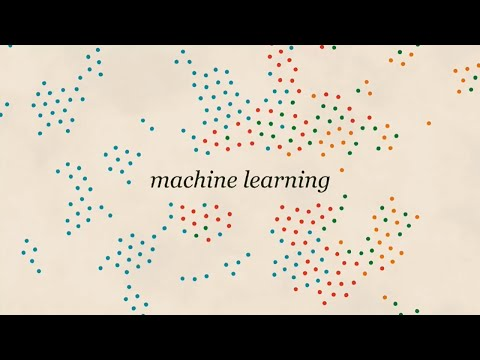

In [2]:
import IPython

IPython.display.YouTubeVideo("59bMh59JQDo")


## Setting up the runtime

I keep experiment metrics in the notebook so this run does not require a Comet account. The imports below list the packages I need. CUDA is useful for training but the code also permits a CPU runtime.

FACE_EPOCHS and FACE_STEPS_PER_EPOCH allow a labelled shorter training run. The defaults retain two full epochs.

In [3]:
%pip install "setuptools<81" --quiet
%pip install mitdeeplearning --no-deps --no-build-isolation --quiet
import mitdeeplearning as mdl
class LocalExperiment:
    """I retain metrics locally so a notebook run needs no service account."""
    def __init__(self):
        self.metrics = {}
        self.parameters = {}
    def log_parameter(self, name, value):
        self.parameters[name] = value
    def log_metric(self, name, value, step=None):
        self.metrics.setdefault(name, []).append(float(value))
    def log_figure(self, figure=None):
        pass
    def log_asset(self, path):
        pass
    def flush(self):
        pass
    def end(self):
        print("Recorded metrics:", {k: v[-1] for k, v in self.metrics.items()})


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\Somil Singh\Documents\Codex\2026-10-03\new-chat\work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
import os
import random
import IPython
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn


torch.manual_seed(7)
np.random.seed(7)
random.seed(7)
torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Runtime:", device)


Runtime: cuda


## Training data

The course combines CelebA face images with ImageNet examples that are not faces. Its separate test images are grouped for comparison. I keep downloaded data in a local data directory.

In [5]:
import h5py

class FaceSubset:
    """I read only the current face batch from disk."""
    def __init__(self, images, indices):
        self.images = images
        self.indices = indices
        self.shape = (len(indices),) + images.shape[1:]
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, item):
        indices = self.indices[item]
        order = np.argsort(indices)
        selected = self.images[indices[order]]
        return selected[np.argsort(order)]

class MemoryEfficientFaceLoader(mdl.lab2.TrainingDatasetLoader):
    """I retain the course batching rules while reading images on demand."""
    def __init__(self, data_path, channels_last=False):
        self.cache = h5py.File(data_path, "r")
        source_images = self.cache["images"]
        array_path = Path(data_path).with_suffix(".images.npy")
        if not array_path.exists():
            # I cache contiguous rows on disk because random HDF5 batches are slow.
            cached = np.lib.format.open_memmap(array_path, mode="w+", dtype=source_images.dtype, shape=source_images.shape)
            chunk_size = source_images.chunks[0] if source_images.chunks else 4096
            for start in range(0, len(source_images), chunk_size):
                cached[start:start + chunk_size] = source_images[start:start + chunk_size]
            cached.flush()
            del cached
        self.images = np.load(array_path, mmap_mode="r")
        self.labels = self.cache["labels"][:].astype(np.float32)
        self.channels_last = channels_last
        self.image_dims = self.images.shape
        self.train_inds = np.random.permutation(np.arange(self.image_dims[0]))
        self.pos_train_inds = self.train_inds[self.labels[self.train_inds, 0] == 1.0]
        self.neg_train_inds = self.train_inds[self.labels[self.train_inds, 0] != 1.0]
    def get_batch(self, n, only_faces=False, p_pos=None, p_neg=None, return_inds=False):
        if only_faces:
            indices = np.random.choice(self.pos_train_inds, size=n, replace=False, p=p_pos)
        else:
            positive = np.random.choice(self.pos_train_inds, size=n // 2, replace=False, p=p_pos)
            negative = np.random.choice(self.neg_train_inds, size=n // 2, replace=False, p=p_neg)
            indices = np.concatenate((positive, negative))
        indices = np.sort(indices)
        # HDF5 cannot reverse a slice. I read the batch before converting BGR to RGB.
        images = (self.images[indices][..., ::-1] / 255.0).astype(np.float32)
        if not self.channels_last:
            images = np.ascontiguousarray(images.transpose(0, 3, 1, 2))
        labels = self.labels[indices]
        return (images, labels, indices) if return_inds else (images, labels)

    def get_all_train_faces(self):
        return FaceSubset(self.images, self.pos_train_inds)

CACHE_DIR = Path("data") / "mitdeeplearning"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Get the training data: both images from CelebA and ImageNet
path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# Create a simple check to avoid re downloading
if path_to_training_data.is_file():
    print(f"Using cached training data from {path_to_training_data}")
else:
    print(f"Downloading training data to {path_to_training_data}")
    url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
    torch.hub.download_url_to_file(url, path_to_training_data)

# Instantiate a TrainingDatasetLoader using the downloaded dataset
channels_last = False
loader = MemoryEfficientFaceLoader(
    path_to_training_data, channels_last=channels_last
)


Using cached training data from data\mitdeeplearning\train_face.h5


I print the training size and take one batch to check how images and binary labels are arranged.

In [6]:
number_of_training_examples = loader.get_train_size()
(images, labels) = loader.get_batch(100)

print("Training examples:", number_of_training_examples)
print("Image shape:", images.shape, "Label shape:", labels.shape)


Training examples: 109914
Image shape: (100, 3, 64, 64) Label shape: (100, 1)


In [7]:
B, C, H, W = images.shape


I inspect a face and a nonface example before choosing an architecture. This is also a quick check of channel order and pixel scaling.

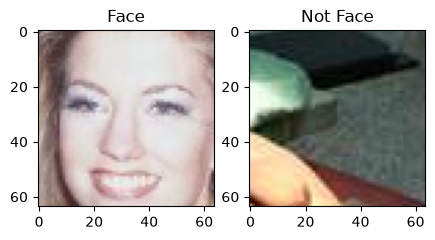

In [8]:
### Examining the CelebA training dataset ###

# @title Change the sliders to look at positive and negative training examples! { run: "auto" }

face_images = images[np.where(labels == 1)[0]].transpose(0, 2, 3, 1)
not_face_images = images[np.where(labels == 0)[0]].transpose(0, 2, 3, 1)

idx_face = 23  # @param {type:"slider", min:0, max:50, step:1}
idx_not_face = 9  # @param {type:"slider", min:0, max:50, step:1}

plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face")
plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face")
plt.grid(False)


## My note on bias

Good average performance does not guarantee similar performance for every group. Dataset coverage can affect what the classifier learns. The four course groups provide a narrow check rather than a complete fairness assessment.

## My standard CNN

I stack four convolution blocks then a dense head. The output is one face logit. BCEWithLogitsLoss combines the sigmoid operation with binary cross entropy during training.

In [9]:
### Define the CNN model ###

n_filters = 12  # base number of convolutional filters
in_channels = images.shape[1]

def make_standard_classifier(n_outputs):
  """Create a standard CNN classifier."""

  # Start by first defining a convolutional block
  class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.relu = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        return x

  # now use the block to define the classifier
  model = nn.Sequential(
      ConvBlock(in_channels, n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(n_filters, 2*n_filters, kernel_size=5, stride=2, padding=2),
      ConvBlock(2*n_filters, 4*n_filters, kernel_size=3, stride=2, padding=1),
      ConvBlock(4*n_filters, 6*n_filters, kernel_size=3, stride=2, padding=1),
      nn.Flatten(),
      nn.Linear(H // 16 * W // 16 * 6 * n_filters, 512),
      nn.ReLU(inplace=True),
      nn.Linear(512, n_outputs),
  )

  return model.to(device)

# call the function to instantiate a classifier model
standard_classifier = make_standard_classifier(n_outputs=1)
print(standard_classifier)


Sequential(
  (0): ConvBlock(
    (conv): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): ConvBlock(
    (conv): Conv2d(12, 24, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (2): ConvBlock(
    (conv): Conv2d(24, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): ConvBlock(
    (conv): Conv2d(48, 72, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (bn): BatchNorm2d(72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=1152, out_features=512, bias=True)
  (6

I train the standard CNN first so the later comparison has a baseline. The learning rate and epoch count are printed with the run.

In [10]:
def create_experiment(project_name, params):
    experiment = LocalExperiment()
    experiment.parameters.update(params)
    print(project_name, params)
    return experiment


6S191_Lab2_Part2_CNN {'batch_size': 32, 'num_epochs': 2, 'learning_rate': 0.0005}


  0%|          | 0/3434 [00:00<?, ?it/s]


  0%|          | 1/3434 [00:00<53:31,  1.07it/s]


  0%|          | 9/3434 [00:01<05:00, 11.41it/s]


Epoch 1 step 0 loss: 0.7285


...

100%|█████████▉| 3420/3434 [00:53<00:00, 65.85it/s]


100%|█████████▉| 3427/3434 [00:54<00:00, 64.75it/s]


100%|██████████| 3434/3434 [00:54<00:00, 63.61it/s]


100%|██████████| 3434/3434 [00:54<00:00, 63.34it/s]


Recorded metrics: {'loss': 0.00014751013077329844}


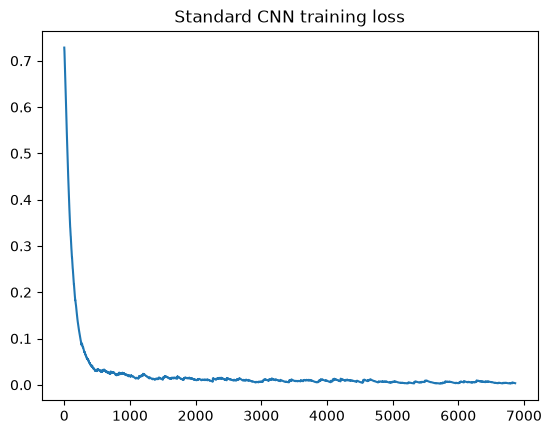

Maximum steps per epoch: full


In [11]:
### Train the standard CNN ###
loss_fn = nn.BCEWithLogitsLoss()
# Training hyperparameters
params = dict(
    batch_size=32,
    num_epochs=int(os.getenv("FACE_EPOCHS", "2")),  # keep small to run faster
    learning_rate=5e-4,
)

experiment = create_experiment("6S191_Lab2_Part2_CNN", params)

optimizer = optim.Adam(
    standard_classifier.parameters(), lr=params["learning_rate"]
)  # define our optimizer
loss_history = mdl.util.LossHistory(smoothing_factor=0.99)  # to record loss evolution
if hasattr(tqdm, "_instances"):
    tqdm._instances.clear()  # clear if it exists

# set the model to train mode
standard_classifier.train()


def standard_train_step(x, y):
    x = torch.from_numpy(x).float().to(device)
    y = torch.from_numpy(y).float().to(device)

    # clear the gradients
    optimizer.zero_grad()

    # feed the images into the model
    logits = standard_classifier(x)
    # Compute the loss
    loss = loss_fn(logits, y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss


# The training loop!
step = 0
for epoch in range(params["num_epochs"]):
    for idx in tqdm(range(min(loader.get_train_size() // params["batch_size"], int(os.getenv("FACE_STEPS_PER_EPOCH", "1000000"))))):
        # Grab a batch of training data and propagate through the network
        x, y = loader.get_batch(params["batch_size"])
        loss = standard_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()

        # Record the loss and plot the evolution of the loss as a function of training
        loss_history.append(loss_value)
        if idx % 500 == 0:
            print(f"Epoch {epoch + 1} step {idx} loss: {float(loss_value):.4f}")

        experiment.log_metric("loss", loss_value, step=step)
        step += 1

experiment.end()

plt.figure()
plt.plot(loss_history.get())
plt.title("Standard CNN training loss")
plt.show()

print("Maximum steps per epoch:", os.getenv("FACE_STEPS_PER_EPOCH", "full"))


## Checking the baseline

This first accuracy uses a sample from the training distribution. I label it as training accuracy because it does not establish generalisation.

In [12]:
standard_classifier.eval()
batch_x, batch_y = loader.get_batch(5000)
predictions = []
with torch.inference_mode():
    for start in range(0, len(batch_x), 64):
        x = torch.from_numpy(batch_x[start:start + 64]).float().to(device)
        predictions.append((torch.sigmoid(standard_classifier(x)) >= 0.5).cpu())
y_pred_standard = torch.cat(predictions).reshape(-1)
acc_standard = (torch.as_tensor(batch_y).reshape(-1) == y_pred_standard).float().mean()
print(f"Training sample accuracy: {acc_standard.item():.4f}")


Training sample accuracy: 0.9976


## Independent face examples

I load the course test faces separately. The labels used for the four groups are the dataset labels and should not be treated as a complete description of identity.

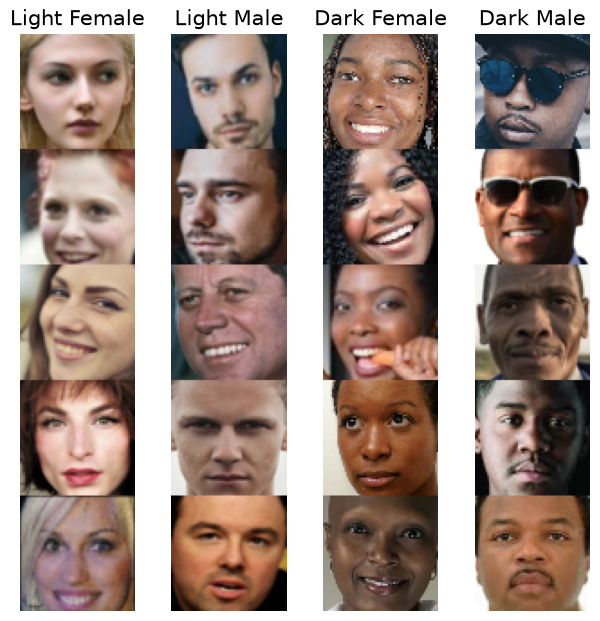

In [13]:
### Load test dataset and plot examples ###

test_faces = mdl.lab2.get_test_faces(channels_last=channels_last)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

fig, axs = plt.subplots(1, len(keys), figsize=(7.5, 7.5))
for i, (group, key) in enumerate(zip(test_faces, keys)):
    axs[i].imshow(np.hstack(group).transpose(1, 2, 0))
    axs[i].set_title(key, fontsize=15)
    axs[i].axis("off")


I compute the mean face probability for each group. A probability bar is a confidence summary rather than a measured classification accuracy.

Text(0.5, 1.0, 'Standard classifier predictions')

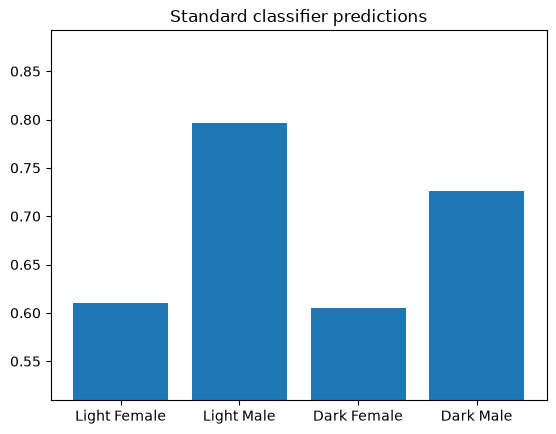

In [14]:
### Evaluate the standard CNN on the test data ###

standard_classifier_probs_list = []  # store each demographic's probabilities

with torch.inference_mode():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = standard_classifier(x)  # [B, 1]
        probs = torch.sigmoid(logits)  # [B, 1]
        probs = torch.squeeze(probs, dim=-1)  # shape [B]
        standard_classifier_probs_list.append(probs.cpu().numpy())

standard_classifier_probs = np.stack(standard_classifier_probs_list, axis=0)


# Plot the prediction accuracies per demographic
xx = range(len(keys))
yy = standard_classifier_probs.mean(axis=1)  # shape [D]
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("Standard classifier predictions")


I compare the bars and look for differences between groups. Small group sizes and a single run limit how much I can infer from the plot.

### My note on interpretation

Representation in the training data is one possible source of unequal performance. Architecture and optimisation also matter. I avoid treating one plot as proof that a system is unbiased.

## Changing the sampling distribution

The DB VAE uses learned latent features to identify less common faces. It then increases their chance of appearing in training batches without requiring demographic annotations for sampling.

## Learning a latent representation

A variational autoencoder predicts the mean and log variance of a latent Gaussian. A sampled latent vector is decoded into an image. Reconstruction encourages useful features while a KL term regularises the distribution.

## My VAE loss

I combine mean absolute reconstruction error with a weighted KL penalty. The weight controls how strongly the latent distribution is pushed toward a standard Gaussian.

For each sample the KL term is half the sum of exp(log variance) plus the squared mean minus one minus log variance. I average the absolute pixel error over channels and spatial dimensions. The code calls the log variance logsigma so I keep that convention consistent with sampling.

In [15]:
### Defining the VAE loss function ###

""" Function to calculate VAE loss given:
      an input x,
      reconstructed output x_recon,
      encoded means mu,
      encoded log variance logsigma,
      weight parameter for the latent loss kl_weight
"""
def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):
    # Define the latent loss. Note this is given in the equation for L_{KL}
    # in the text block directly above
    latent_loss = 0.5 * torch.sum(torch.exp(logsigma) + mu**2 - 1.0 - logsigma, dim=1)

    # Define the reconstruction loss as the mean absolute pixel wise
    # difference between the input and reconstruction. Hint: you'll need to
    # use torch.mean and specify the dimensions to reduce over.
    # For example, reconstruction loss needs to average
    # over the height, width and channel image dimensions.
    # https://pytorch.org/docs/stable/generated/torch.mean.html
    reconstruction_loss = torch.mean(torch.abs(x - x_recon), dim=(1, 2, 3))

    # Define the VAE loss. Note this is given in the equation for L_{VAE}
    # in the text block directly above
    vae_loss = kl_weight * latent_loss + reconstruction_loss

    return vae_loss


I now combine the VAE objective with face classification. The reconstruction term should apply to faces while the classification term should apply to every example.

## Sampling without breaking the gradient

I draw noise from a standard Gaussian and form the latent vector as mean plus exp(half the log variance) times noise. This keeps the mean and variance connected to the loss.

In [16]:
### VAE Reparameterization ###

"""Reparameterization trick by sampling from an isotropic unit Gaussian.
# Arguments
    z_mean, z_logsigma (tensor): mean and log variance of latent distribution (Q(z|X))
# Returns
    z (tensor): sampled latent vector
"""
def sampling(z_mean, z_logsigma):
    # Generate random noise with the same shape as z_mean, sampled from a standard normal distribution (mean=0, std=1)
    eps = torch.randn_like(z_mean)

    # Define the reparameterization computation!
    # Note the equation is given in the text block immediately above.
    z = z_mean + torch.exp(0.5 * z_logsigma) * eps

    return z


## My DB VAE

The encoder returns a face logit plus two latent parameter vectors. The decoder reconstructs an image from the sampled latent representation.

The classification output stays separate from the latent parameters. Both tasks share the encoder so I check the output slices carefully.

## Combining the objectives

Every sample contributes a classification loss. Only samples labelled as faces contribute the VAE loss. I reshape the labels to avoid accidental broadcasting across the batch.

In [17]:
### Loss function for DB VAE ###

"""Loss function for DB-VAE.
# Arguments
    x: true input x
    x_pred: reconstructed x
    y: true label (face or not face)
    y_logit: predicted labels
    mu: mean of latent distribution (Q(z|X))
    logsigma: log variance of latent distribution (Q(z|X))
# Returns
    total_loss: DB-VAE total loss
    classification_loss = DB-VAE classification loss
"""
def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):
    # call the relevant function to obtain VAE loss
    vae_loss = vae_loss_function(x, x_pred, mu, logsigma)

    # define the classification loss using binary_cross_entropy
    # https://pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy_with_logits.html
    classification_loss = F.binary_cross_entropy_with_logits(
        y_logit.reshape(-1), y.reshape(-1), reduction="none"
    )

    # Use the training data labels to create variable face_indicator:
    #   indicator that reflects which training data are images of faces
    y = y.reshape(-1).float()
    face_indicator = (y == 1.0).float()

    # define the DB VAE total loss! Use torch.mean to average over all
    # samples
    total_loss = torch.mean(classification_loss + face_indicator * vae_loss)

    return total_loss, classification_loss


## Building the decoder

I project the latent vector into a small feature map then use transposed convolutions to reach a 64 by 64 RGB image. The final output shape must match the input.

In [18]:
### Define the decoder portion of the DB VAE ###

n_filters = 12  # base number of convolutional filters, same as standard CNN
latent_dim = 100  # number of latent variables


def make_face_decoder_network(latent_dim=100, n_filters=12):
    """
    Function builds a face-decoder network.

    Args:
        latent_dim (int): the dimension of the latent representation
        n_filters (int): base number of convolutional filters

    Returns:
        decoder_model (nn.Module): the decoder network
    """

    class FaceDecoder(nn.Module):
        def __init__(self, latent_dim, n_filters):
            super(FaceDecoder, self).__init__()

            self.latent_dim = latent_dim
            self.n_filters = n_filters

            # Linear (fully connected) layer to project from latent space
            # to a 4 x 4 feature map with (6*n_filters) channels
            self.linear = nn.Sequential(
                nn.Linear(latent_dim, 4 * 4 * 6 * n_filters), nn.ReLU()
            )

            # Convolutional upsampling (inverse of an encoder)
            self.deconv = nn.Sequential(
                # [B, 6n_filters, 4, 4] -> [B, 4n_filters, 8, 8]
                nn.ConvTranspose2d(
                    in_channels=6 * n_filters,
                    out_channels=4 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 4n_filters, 8, 8] -> [B, 2n_filters, 16, 16]
                nn.ConvTranspose2d(
                    in_channels=4 * n_filters,
                    out_channels=2 * n_filters,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, 2n_filters, 16, 16] -> [B, n_filters, 32, 32]
                nn.ConvTranspose2d(
                    in_channels=2 * n_filters,
                    out_channels=n_filters,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
                nn.ReLU(),
                # [B, n_filters, 32, 32] -> [B, 3, 64, 64]
                nn.ConvTranspose2d(
                    in_channels=n_filters,
                    out_channels=3,
                    kernel_size=5,
                    stride=2,
                    padding=2,
                    output_padding=1,
                ),
            )

        def forward(self, z):
            """
            Forward pass of the decoder.

            Args:
                z (Tensor): Latent codes of shape [batch_size, latent_dim].

            Returns:
                Tensor of shape [batch_size, 3, 64, 64], representing
                the reconstructed images.
            """
            x = self.linear(z)  # [B, 4*4*6*n_filters]
            x = x.view(-1, 6 * self.n_filters, 4, 4)  # [B, 6n_filters, 4, 4]

            # Upsample through transposed convolutions
            x = self.deconv(x)  # [B, 3, 64, 64]
            return x

    return FaceDecoder(latent_dim, n_filters)


I connect the encoder and decoder in one module. I pass the selected latent dimension to both so changing it does not silently create a shape mismatch.

In [19]:
### Defining and creating the DB VAE ###


class DB_VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(DB_VAE, self).__init__()
        self.latent_dim = latent_dim

        # Define the number of outputs for the encoder.
        self.encoder = make_standard_classifier(n_outputs=2 * latent_dim + 1)
        self.decoder = make_face_decoder_network(latent_dim=self.latent_dim)

    # function to feed images into encoder, encode the latent space and output
    def encode(self, x):
        encoder_output = self.encoder(x)

        # classification prediction
        y_logit = encoder_output[:, 0].unsqueeze(-1)
        # latent variable distribution parameters
        z_mean = encoder_output[:, 1 : self.latent_dim + 1]
        z_logsigma = encoder_output[:, self.latent_dim + 1 :]

        return y_logit, z_mean, z_logsigma

    # VAE reparameterization: given a mean and logsigma, sample latent variables
    def reparameterize(self, z_mean, z_logsigma):
        # call the sampling function defined above
        z = sampling(z_mean, z_logsigma)
        return z

    # Decode the latent space and output reconstruction
    def decode(self, z):
        # use the decoder to output the reconstruction
        reconstruction = self.decoder(z)
        return reconstruction

    # The forward function will be used to pass inputs x through the core VAE
    def forward(self, x):
        # Encode input to a prediction and latent space
        y_logit, z_mean, z_logsigma = self.encode(x)

        # reparameterization
        z = self.reparameterize(z_mean, z_logsigma)

        # reconstruction
        recon = self.decode(z)

        return y_logit, z_mean, z_logsigma, recon

    # Predict face or not face logit for given input x
    def predict(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        return y_logit

dbvae = DB_VAE(latent_dim)


The forward pass returns the face logit then the latent mean and log variance followed by the reconstruction. Keeping that order explicit makes the training step easier to inspect.

### My note on adaptive sampling

Rare latent values receive larger sampling weights. This may expose the model to more varied faces but rarity in the latent space is not automatically the same thing as demographic underrepresentation.

## Recomputing sampling weights

I estimate a histogram for each latent dimension. Smoothing prevents a nearly empty bin from receiving an excessive weight.

I encode faces in small batches and retain only the latent means. This avoids keeping every reconstruction in memory and restores the previous model mode afterward.

In [20]:
def get_latent_mu(images, dbvae, batch_size=64):
    was_training = dbvae.training
    dbvae.eval()
    all_z_mean = []
    raw_channels_last = images.shape[-1] == 3
    try:
        with torch.inference_mode():
            for start in range(0, len(images), batch_size):
                batch = torch.as_tensor(images[start:start + batch_size], dtype=torch.float32, device=device)
                if raw_channels_last:
                    # I match the course loader's conversion from raw BGR pixels.
                    batch = batch.flip(-1).permute(0, 3, 1, 2) / 255.0
                _, z_mean, _ = dbvae.encode(batch)
                all_z_mean.append(z_mean.cpu())
    finally:
        dbvae.train(was_training)
    return torch.cat(all_z_mean).numpy()


I invert the smoothed bin densities and normalise the resulting weights. For each face I keep the largest weight across latent dimensions then normalise again.

In [21]:
### Resampling algorithm for DB VAE ###

"""Function that recomputes the sampling probabilities for images within a batch
      based on how they distribute across the training data"""
def get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing the sampling probabilities")

    # run the input batch and get the latent variable means
    mu = get_latent_mu(images, dbvae)

    # sampling probabilities for the images
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

    # consider the distribution for each latent variable
    for i in range(mu.shape[1]):
        latent_distribution = mu[:, i]
        # generate a histogram of the latent distribution
        hist_density, bin_edges = np.histogram(
            latent_distribution, density=True, bins=bins
        )

        # find which latent bin every data sample falls in
        bin_edges[0] = -float("inf")
        bin_edges[-1] = float("inf")

        # call the digitize function to find which bins in the latent distribution
        #    every data sample falls in to
        # https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.digitize.html
        bin_idx = np.digitize(latent_distribution, bin_edges)

        # smooth the density function
        hist_smoothed_density = hist_density + smoothing_fac
        hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)

        # invert the density function
        p = 1.0 / (hist_smoothed_density[bin_idx - 1])

        # normalize all probabilities
        p = p / np.sum(p)

        # update sampling probabilities by considering whether the newly
        #     computed p is greater than the existing sampling probabilities.
        training_sample_p = np.maximum(training_sample_p, p)

    # final normalization
    training_sample_p /= np.sum(training_sample_p)

    return training_sample_p


## Training with the new weights

At the start of each epoch I update the face sampling probabilities. I then restore training mode before taking gradient steps.

6S191_Lab2_Part2_DBVAE {'batch_size': 32, 'learning_rate': 0.0005, 'latent_dim': 100, 'num_epochs': 2}
Starting epoch 1/2
Recomputing the sampling probabilities


  0%|          | 0/3434 [00:00<?, ?it/s]


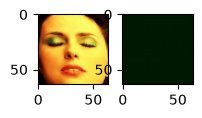

  0%|          | 1/3434 [00:00<13:31,  4.23it/s]


  0%|          | 7/3434 [00:00<02:16, 25.04it/s]


  0%|          | 15/3434 [00:00<01:21, 42.01it/s]


  1%|          | 21/3434 [00:00<01:11, 47.46it/s]


  1%|          | 28/3434 [00:00<01:03, 53.60it/s]


...

 14%|█▎        | 472/3434 [00:08<00:53, 55.73it/s]


 14%|█▍        | 478/3434 [00:08<00:51, 56.88it/s]


 14%|█▍        | 485/3434 [00:08<00:50, 58.02it/s]


 14%|█▍        | 491/3434 [00:08<00:52, 56.31it/s]


 14%|█▍        | 497/3434 [00:08<00:53, 54.75it/s]


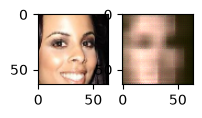

 15%|█▍        | 503/3434 [00:08<01:02, 46.78it/s]


 15%|█▍        | 509/3434 [00:08<00:59, 48.83it/s]


 15%|█▍        | 515/3434 [00:08<00:58, 49.94it/s]


 15%|█▌        | 521/3434 [00:08<00:56, 51.25it/s]


 15%|█▌        | 528/3434 [00:09<00:53, 54.31it/s]


...

 28%|██▊       | 972/3434 [00:16<00:44, 55.48it/s]


 28%|██▊       | 978/3434 [00:16<00:45, 53.82it/s]


 29%|██▊       | 984/3434 [00:17<00:45, 54.16it/s]


 29%|██▉       | 990/3434 [00:17<00:44, 54.96it/s]


 29%|██▉       | 996/3434 [00:17<00:43, 55.42it/s]


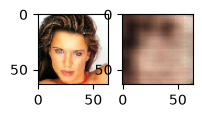

 29%|██▉       | 1002/3434 [00:17<00:49, 48.96it/s]


 29%|██▉       | 1008/3434 [00:17<00:47, 51.30it/s]


 30%|██▉       | 1015/3434 [00:17<00:43, 55.21it/s]


 30%|██▉       | 1023/3434 [00:17<00:40, 59.84it/s]


 30%|██▉       | 1030/3434 [00:17<00:38, 62.29it/s]


...

 43%|████▎     | 1470/3434 [00:25<00:36, 53.88it/s]


 43%|████▎     | 1476/3434 [00:25<00:35, 55.52it/s]


 43%|████▎     | 1482/3434 [00:25<00:34, 55.92it/s]


 43%|████▎     | 1488/3434 [00:25<00:34, 56.81it/s]


 44%|████▎     | 1495/3434 [00:26<00:33, 57.97it/s]


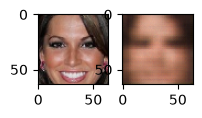

 44%|████▎     | 1501/3434 [00:26<00:40, 48.21it/s]


 44%|████▍     | 1508/3434 [00:26<00:36, 53.36it/s]


 44%|████▍     | 1515/3434 [00:26<00:34, 55.10it/s]


 44%|████▍     | 1521/3434 [00:26<00:34, 55.78it/s]


 44%|████▍     | 1528/3434 [00:26<00:33, 57.58it/s]


...

 57%|█████▋    | 1969/3434 [00:33<00:24, 60.77it/s]


 58%|█████▊    | 1976/3434 [00:34<00:23, 60.93it/s]


 58%|█████▊    | 1983/3434 [00:34<00:25, 57.40it/s]


 58%|█████▊    | 1989/3434 [00:34<00:25, 56.62it/s]


 58%|█████▊    | 1995/3434 [00:34<00:25, 57.25it/s]


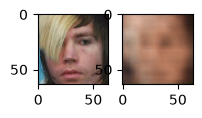

 58%|█████▊    | 2001/3434 [00:34<00:30, 47.36it/s]


 58%|█████▊    | 2007/3434 [00:34<00:28, 49.75it/s]


 59%|█████▊    | 2013/3434 [00:34<00:27, 51.19it/s]


 59%|█████▉    | 2019/3434 [00:34<00:27, 51.68it/s]


 59%|█████▉    | 2025/3434 [00:35<00:27, 51.31it/s]


...

 72%|███████▏  | 2469/3434 [00:42<00:16, 59.72it/s]


 72%|███████▏  | 2476/3434 [00:42<00:16, 58.57it/s]


 72%|███████▏  | 2483/3434 [00:42<00:15, 60.08it/s]


 73%|███████▎  | 2490/3434 [00:42<00:15, 59.54it/s]


 73%|███████▎  | 2496/3434 [00:43<00:15, 58.83it/s]


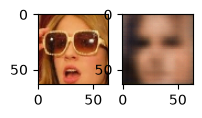

 73%|███████▎  | 2502/3434 [00:43<00:18, 49.60it/s]


 73%|███████▎  | 2509/3434 [00:43<00:17, 52.98it/s]


 73%|███████▎  | 2516/3434 [00:43<00:16, 54.77it/s]


 73%|███████▎  | 2522/3434 [00:43<00:16, 55.23it/s]


 74%|███████▎  | 2528/3434 [00:43<00:16, 55.30it/s]


...

 86%|████████▋ | 2969/3434 [00:51<00:06, 69.84it/s]


 87%|████████▋ | 2976/3434 [00:51<00:06, 68.01it/s]


 87%|████████▋ | 2983/3434 [00:51<00:06, 67.39it/s]


 87%|████████▋ | 2990/3434 [00:51<00:06, 66.89it/s]


 87%|████████▋ | 2997/3434 [00:51<00:06, 66.19it/s]


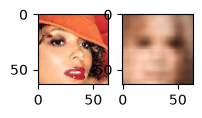

 87%|████████▋ | 3004/3434 [00:51<00:07, 55.48it/s]


 88%|████████▊ | 3012/3434 [00:51<00:07, 59.59it/s]


 88%|████████▊ | 3020/3434 [00:51<00:06, 63.51it/s]


 88%|████████▊ | 3028/3434 [00:51<00:06, 65.83it/s]


 88%|████████▊ | 3035/3434 [00:52<00:06, 66.31it/s]


...

100%|█████████▉| 3427/3434 [00:58<00:00, 54.04it/s]


100%|█████████▉| 3433/3434 [00:58<00:00, 53.35it/s]


100%|██████████| 3434/3434 [00:58<00:00, 58.90it/s]


Starting epoch 2/2
Recomputing the sampling probabilities


  0%|          | 0/3434 [00:00<?, ?it/s]


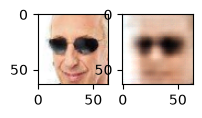

  0%|          | 3/3434 [00:00<02:16, 25.13it/s]


  0%|          | 11/3434 [00:00<01:05, 51.99it/s]


  0%|          | 17/3434 [00:00<01:01, 55.34it/s]


  1%|          | 24/3434 [00:00<00:58, 58.60it/s]


  1%|          | 31/3434 [00:00<00:56, 59.78it/s]


...

 14%|█▎        | 470/3434 [00:07<00:45, 64.71it/s]


 14%|█▍        | 477/3434 [00:07<00:46, 64.08it/s]


 14%|█▍        | 484/3434 [00:07<00:45, 64.63it/s]


 14%|█▍        | 491/3434 [00:07<00:45, 64.11it/s]


 15%|█▍        | 498/3434 [00:07<00:46, 63.41it/s]


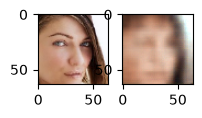

 15%|█▍        | 505/3434 [00:07<00:56, 52.30it/s]


 15%|█▍        | 512/3434 [00:07<00:53, 54.96it/s]


 15%|█▌        | 518/3434 [00:08<00:53, 54.24it/s]


 15%|█▌        | 525/3434 [00:08<00:51, 56.75it/s]


 15%|█▌        | 532/3434 [00:08<00:48, 60.24it/s]


...

 28%|██▊       | 968/3434 [00:15<00:43, 56.24it/s]


 28%|██▊       | 974/3434 [00:15<00:44, 54.78it/s]


 29%|██▊       | 980/3434 [00:15<00:44, 55.27it/s]


 29%|██▊       | 987/3434 [00:15<00:42, 58.02it/s]


 29%|██▉       | 995/3434 [00:15<00:39, 61.95it/s]


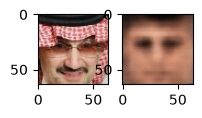

 29%|██▉       | 1002/3434 [00:15<00:45, 52.95it/s]


 29%|██▉       | 1008/3434 [00:15<00:45, 53.06it/s]


 30%|██▉       | 1014/3434 [00:16<00:45, 53.74it/s]


 30%|██▉       | 1020/3434 [00:16<00:44, 54.85it/s]


 30%|██▉       | 1027/3434 [00:16<00:42, 56.92it/s]


...

 43%|████▎     | 1471/3434 [00:23<00:33, 59.35it/s]


 43%|████▎     | 1477/3434 [00:23<00:33, 58.78it/s]


 43%|████▎     | 1483/3434 [00:23<00:35, 55.00it/s]


 43%|████▎     | 1489/3434 [00:23<00:34, 56.04it/s]


 44%|████▎     | 1496/3434 [00:23<00:32, 58.92it/s]


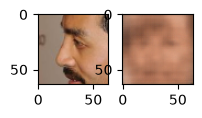

 44%|████▎     | 1502/3434 [00:24<00:40, 48.18it/s]


 44%|████▍     | 1508/3434 [00:24<00:38, 49.95it/s]


 44%|████▍     | 1514/3434 [00:24<00:37, 51.61it/s]


 44%|████▍     | 1520/3434 [00:24<00:36, 52.66it/s]


 44%|████▍     | 1527/3434 [00:24<00:34, 55.09it/s]


...

 57%|█████▋    | 1970/3434 [00:31<00:24, 58.80it/s]


 58%|█████▊    | 1977/3434 [00:32<00:24, 59.07it/s]


 58%|█████▊    | 1983/3434 [00:32<00:24, 58.41it/s]


 58%|█████▊    | 1989/3434 [00:32<00:25, 57.55it/s]


 58%|█████▊    | 1995/3434 [00:32<00:24, 58.15it/s]


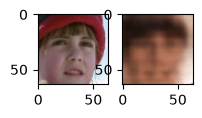

 58%|█████▊    | 2001/3434 [00:32<00:29, 49.23it/s]


 58%|█████▊    | 2008/3434 [00:32<00:26, 54.46it/s]


 59%|█████▊    | 2015/3434 [00:32<00:24, 57.21it/s]


 59%|█████▉    | 2021/3434 [00:32<00:24, 57.79it/s]


 59%|█████▉    | 2027/3434 [00:32<00:25, 55.61it/s]


...

 72%|███████▏  | 2473/3434 [00:40<00:16, 56.82it/s]


 72%|███████▏  | 2479/3434 [00:41<00:17, 54.22it/s]


 72%|███████▏  | 2485/3434 [00:41<00:17, 54.74it/s]


 73%|███████▎  | 2492/3434 [00:41<00:16, 56.70it/s]


 73%|███████▎  | 2499/3434 [00:41<00:16, 58.05it/s]


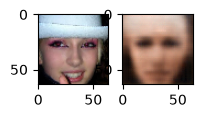

 73%|███████▎  | 2505/3434 [00:41<00:19, 48.40it/s]


 73%|███████▎  | 2511/3434 [00:41<00:18, 49.05it/s]


 73%|███████▎  | 2517/3434 [00:41<00:18, 50.46it/s]


 73%|███████▎  | 2523/3434 [00:41<00:17, 51.26it/s]


 74%|███████▎  | 2529/3434 [00:42<00:17, 51.17it/s]


...

 87%|████████▋ | 2971/3434 [00:49<00:07, 60.41it/s]


 87%|████████▋ | 2978/3434 [00:49<00:07, 60.14it/s]


 87%|████████▋ | 2985/3434 [00:49<00:07, 58.81it/s]


 87%|████████▋ | 2991/3434 [00:49<00:07, 57.18it/s]


 87%|████████▋ | 2997/3434 [00:50<00:07, 56.11it/s]


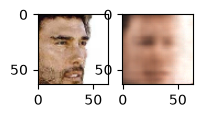

 87%|████████▋ | 3003/3434 [00:50<00:08, 48.06it/s]


 88%|████████▊ | 3011/3434 [00:50<00:07, 54.20it/s]


 88%|████████▊ | 3017/3434 [00:50<00:07, 55.58it/s]


 88%|████████▊ | 3023/3434 [00:50<00:07, 56.72it/s]


 88%|████████▊ | 3029/3434 [00:50<00:07, 57.24it/s]


...

100%|█████████▉| 3420/3434 [00:57<00:00, 53.50it/s]


100%|█████████▉| 3426/3434 [00:57<00:00, 54.65it/s]


100%|█████████▉| 3433/3434 [00:57<00:00, 56.64it/s]


100%|██████████| 3434/3434 [00:57<00:00, 59.32it/s]


Recorded metrics: {'loss': 0.06470407545566559}
Maximum steps per epoch: full


In [22]:
### Training the DB VAE ###

# Hyperparameters
params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=int(os.getenv("FACE_EPOCHS", "2")),  # DB-VAE needs slightly more epochs to train
)

experiment = create_experiment("6S191_Lab2_Part2_DBVAE", params)

# instantiate a new DB VAE model and optimizer
dbvae = DB_VAE(params["latent_dim"]).to(device)
optimizer = optim.Adam(dbvae.parameters(), lr=params["learning_rate"])


def debiasing_train_step(x, y):
    optimizer.zero_grad()

    y_logit, z_mean, z_logsigma, x_recon = dbvae(x)

    # call the DB_VAE loss function to compute the loss
    loss, class_loss = debiasing_loss_function(x, x_recon, y, y_logit, z_mean, z_logsigma)

    loss.backward()
    optimizer.step()

    return loss


# get training faces from data loader
all_faces = loader.get_all_train_faces()

# The training loop. outer loop iterates over the number of epochs
step = 0
for i in range(params["num_epochs"]):
    dbvae.train()
    print("Starting epoch {}/{}".format(i + 1, params["num_epochs"]))

    # Recompute data sampling proabilities
    # recompute the sampling probabilities for debiasing
    p_faces = get_training_sample_probabilities(all_faces, dbvae)
    dbvae.train()

    # get a batch of training data and compute the training step
    for j in tqdm(range(min(loader.get_train_size() // params["batch_size"], int(os.getenv("FACE_STEPS_PER_EPOCH", "1000000"))))):
        # load a batch of data
        (x, y) = loader.get_batch(params["batch_size"], p_pos=p_faces)
        x = torch.from_numpy(x).float().to(device)
        y = torch.from_numpy(y).float().to(device)

        # loss optimization
        loss = debiasing_train_step(x, y)
        loss_value = loss.detach().cpu().numpy()
        experiment.log_metric("loss", loss_value, step=step)

        # plot the progress every 200 steps
        if j % 500 == 0:
            mdl.util.plot_sample(x, y, dbvae, backend="pt")

        step += 1

experiment.end()

print("Maximum steps per epoch:", os.getenv("FACE_STEPS_PER_EPOCH", "full"))


The next cells evaluate the trained DB VAE. Completing training is not enough to claim that debiasing worked.

### My note on the comparison

I compare group probability summaries for both models. I would also need thresholded recall and false positive measurements on larger held out groups for a stronger assessment.

## Comparing test predictions

I put both models in evaluation mode and use the same test groups. The chart displays mean predicted face probability for each model.

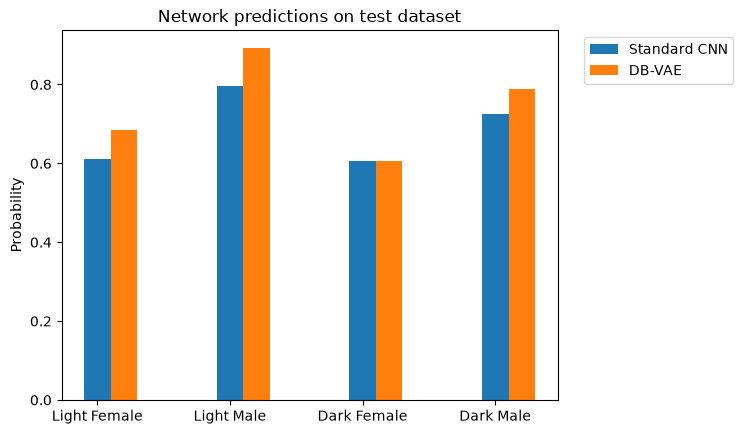

In [23]:
dbvae.eval()
dbvae.to(device)
dbvae_logits_list = []
for face in test_faces:
    face = np.asarray(face, dtype=np.float32)
    face = torch.from_numpy(face).to(device)

    # Forward pass to get the classification logit
    with torch.inference_mode():
        logit = dbvae.predict(face)

    dbvae_logits_list.append(logit.detach().cpu().numpy())

dbvae_logits_array = np.concatenate(dbvae_logits_list, axis=0)
dbvae_logits_tensor = torch.from_numpy(dbvae_logits_array)
dbvae_probs_tensor = torch.sigmoid(dbvae_logits_tensor)
dbvae_probs_array = dbvae_probs_tensor.squeeze(dim=-1).numpy()

xx = np.arange(len(keys))

std_probs_mean = standard_classifier_probs.mean(axis=1)
dbvae_probs_mean = dbvae_probs_array.reshape(len(keys), -1).mean(axis=1)

plt.bar(xx, std_probs_mean, width=0.2, label="Standard CNN")
plt.bar(xx + 0.2, dbvae_probs_mean, width=0.2, label="DB-VAE")

plt.xticks(xx, keys)
plt.title("Network predictions on test dataset")
plt.ylabel("Probability")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()


## What I would investigate next

I would repeat the experiment with several seeds and report group sample sizes. I would also inspect the sampled faces and test whether the latent rarity weights concentrate on noise. This notebook is an experiment in adaptive sampling rather than a certification of fairness.